In [ ]:
# Install fast f1
!pip install fastf1

In [ ]:
# Import packages
import fastf1
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from fastf1 import plotting
import seaborn as sns
import matplotlib.ticker as ticker

In [ ]:
# Return a dictionary between driver name and team color within event
def driver_color(drivers, event):
    palette = {driver: plotting.get_driver_style(identifier=driver, style=['color'], session=event)['color'] for driver in drivers}
    return palette

In [ ]:
# Return the Tyre compound color dictionary
def compound_colors(event):
    compounds = ["SOFT", "MEDIUM", "HARD", "INTERMEDIATE", "WET"]
    colors = {c: fastf1.plotting.get_compound_color(c, session=event) for c in compounds}
    return colors

In [ ]:
# Gap in seconds from driver 2 to driver 1 in seconds
def gap_drivers(driver1, driver2):
   driver1['gap'] =  driver1['Time'].dt.total_seconds() - driver2['Time'].dt.total_seconds()
   return driver1[['LapNumber', 'gap']]

In [ ]:
# Assuming fuel in kg, compute the fuel factor for +0.03s per kg of fuel
def fuel_factor(kg, n_laps):
    return (kg*0.03)/n_laps

In [ ]:
# Compute the corrected lap time given the fuel factor
def laptime_corrected(driver, fuel_factor, session):
    laps = session.laps.pick_drivers(driver).pick_quicklaps().reset_index()
    laps = laps[laps['TrackStatus']=='1'].copy()
    remaining = session.total_laps - laps['LapNumber']
    laps['LapTimeCorrected'] = laps['LapTime'].dt.total_seconds() - (remaining + 0.5) * fuel_factor
    return laps

In [ ]:
# Load 2026 Barcelona Race
barc_race = fastf1.get_session(2026, 'Barcelona', 'R')
barc_race.load()

In [ ]:
# Load HAM and RUS lap data and include lap time in seconds
HAM = barc_race.laps.pick_drivers('HAM').reset_index(drop = True)
RUS = barc_race.laps.pick_drivers('RUS').reset_index(drop = True)
RUS['LapTimeS'] = RUS['LapTime'].dt.total_seconds()
HAM['LapTimeS'] = HAM['LapTime'].dt.total_seconds()
HAM_RUS = pd.concat([HAM, RUS], ignore_index = True)

In [ ]:
# Plot of HAM and RUS laptimes with compound of each stint
plt.subplots(figsize=(12,8))
sns.lineplot(x = 'LapNumber', y = 'LapTimeS', data = HAM_RUS, 
             hue = 'Driver', legend = False, 
             palette = driver_color(['HAM', 'RUS'], barc_race))
ax = sns.scatterplot(x='LapNumber', y='LapTimeS', data= HAM_RUS,
    hue='Driver', style='Compound',palette=driver_color(['HAM', 'RUS'], barc_race),
    edgecolor = '#4d4d4d', s=80)
ax.set_xlim(0, 67)
ax.xaxis.set_major_locator(ticker.MultipleLocator(2)) 
plt.xlabel("Lap Number")
plt.ylabel("Lap Time [s]")
plt.show()

In [ ]:
# Plot real gap between RUS and HAM in seconds
fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(x='LapNumber', y='gap', data=gap_drivers(RUS, HAM))
ax.set_xlim(0, 67)
ax.xaxis.set_major_locator(ticker.MultipleLocator(2)) 
ax.set_xlabel("Lap Number")
ax.set_ylabel("Gap [s]")
ax.set_title("Gap from HAM to RUS")
plt.grid(axis='x', alpha=0.3)

In [ ]:
# Obtain each driver stint lenght and tyre compound per stint
stints = barc_race.laps[["Driver", "Stint", "Compound", "LapNumber"]]
stints = stints.groupby(["Driver", "Stint", "Compound"])
stints = stints.count().reset_index()
stints = stints.rename(columns={"LapNumber": "StintLength"})

In [ ]:
# Visualization of hyphotetical strategy for Hamilton with a stop at Lap n

drivers = ['HAM', 'RUS']

n = 45
ham = stints[stints["Driver"] == "HAM"].copy()
extra_laps = n - 41
ham.iloc[2, ham.columns.get_loc("StintLength")] += extra_laps  # Stretch Hamilton stint 3 by the amount of extra laps
ham.iloc[3, ham.columns.get_loc("StintLength")] -= extra_laps 

fig, ax = plt.subplots(figsize=(12,1))

for driver in drivers:
    previous_stint_end = 0
    if driver == 'HAM':
        driver_stints = ham
    else:
        driver_stints = stints[stints["Driver"] == driver]
    for _, row in driver_stints.iterrows():
        color = fastf1.plotting.get_compound_color(row["Compound"], session=barc_race)
        ax.barh(y=driver, width=row["StintLength"], left=previous_stint_end, color=color, edgecolor="black")
        previous_stint_end += row["StintLength"]  # lap number in which the next stint starts

ticks = list(ax.get_xticks())    # create ticks on the x axis
ticks.append(n)
ticks = sorted(ticks)
ax.set_xticks(ticks)

labels = [str(int(tick)) if tick != n else "n" for tick in ticks]  #label the hyphotetical stop n
ax.set_xticklabels(labels)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.show()

In [ ]:
# Load fuel factor and tyre compound colors for Barcelona
fuel_f = fuel_factor(70, barc_race.total_laps)
tyre_colors = compound_colors(barc_race)

In [ ]:
# Linear regression Visualization of Tyre age ~ Lap Time
HAM_corr = laptime_corrected('HAM',fuel_f,barc_race)
HAM_stint4 = HAM_corr[HAM_corr['Stint']== 4].copy()
sns.regplot( data = HAM_stint4, x = 'TyreLife', y = 'LapTimeCorrected', color = tyre_colors['HARD'], 
             scatter_kws={"edgecolors": "black"}, line_kws={"color": "lightblue"} )
plt.xlabel('Tyre age')
plt.ylabel('Lap Time [s]')
plt.title('HAM Stint 4 Linear Regression')
plt.show()

In [ ]:
# Coefficients of linear regression on Fuel-corrected laps of a given stint 
def fit_degradation(stint_laps):
    x = stint_laps['TyreLife'].to_numpy(dtype=float)
    y = stint_laps['LapTimeCorrected'].to_numpy(dtype=float)
    deg, base = np.polyfit(x, y, 1)  #linear fit of tyre age ~ corrected lap time
    return float(base), float(deg) # the coefficient can be interpreted as tyre degradation: extra m seconds per lap.

In [ ]:
# Given a tyre compound, for each driver who used that compound, return the latest stint in which the compound was used. 
def compound_stint(compound, event, min_laps=3):
    results = {}
    drivers = [event.get_driver(d)["Abbreviation"] for d in event.drivers]
    for driver in drivers:
        laps = event.laps.pick_drivers(driver).copy().reset_index()
        counts = laps.loc[(laps['Compound'] == compound) & (laps['Stint'] != 1), 'Stint'].value_counts() 
        # captures the length of each stint on the given tyre compound, as long as the driver didnt start on hard tyres
        qualified = counts[counts>=min_laps] #only keep representative stints of length at least 3
        if not qualified.empty:
            results[driver] = float(qualified.index.max()) #return only the latest stint on the given tyre compound
    return results

In [ ]:
# We choose the latest stint for each driver in Barcelona because Hamilton also used hard tyres on his last stint. 
compound_stint('HARD', barc_race)

In [ ]:
# Given a stint 
def fit_stint(driver, stint_number):
    laps_corr = laptime_corrected(driver, fuel_f, barc_race)
    stint   = laps_corr[laps_corr['Stint']== stint_number].copy()
    b, m = fit_degradation(stint)
    return b, m

In [ ]:
# Given a stint, perform linear regression on the previous stint to predict in-lap time
def predicted_inlap(driver, stint):
    laps = barc_race.laps.pick_drivers(driver).reset_index()

    stint_laps = laps[laps['Stint'] == stint-1]
    
    in_lap = stint_laps['LapNumber'].max()
   
    b, m = fit_stint(driver, stint-1)
   
    tyre_age = stint_laps.loc[stint_laps['LapNumber'] == in_lap, 'TyreLife'].iloc[0]
   
    laptime = b+ tyre_age * m+ (barc_race.total_laps - in_lap + 0.5) * fuel_f

    return float(laptime)

In [ ]:
# Given a stint, perform linear regression on the current stint to predict out-lap time
def predicted_outlap(driver, stint):
    laps = barc_race.laps.pick_drivers(driver).reset_index()
    
    stint_laps = laps[laps['Stint'] == stint]
    
    out_lap = stint_laps['LapNumber'].min()
    
    b, m = fit_stint(driver, stint)
    
    tyre_age = stint_laps.loc[stint_laps['LapNumber'] == out_lap, 'TyreLife'].iloc[0]
    
    laptime = b + tyre_age * m+ (barc_race.total_laps - out_lap + 0.5) * fuel_f
    
    return float(laptime)

In [ ]:
# Given tyre compound, compute the warmup penalty for each driver in their out-lap.
def warmup_gap(compound, event):
    gap_compound = {}
    compound_stints = compound_stint(compound, event)
    for driver, stint_number in compound_stints.items():
        
        laps = event.laps.pick_drivers(driver).copy().reset_index()
        stint = laps[laps['Stint']==stint_number] # record the current stint
        prev_stint  = laps[laps['Stint']==stint_number-1] # record the previous stint
        
        in_lap_number = prev_stint['LapNumber'].max()  # record the in-lap number
        out_lap_number = stint['LapNumber'].min() # record the out-lap number (usually this equals in-lap +1)
        
        in_predicted = predicted_inlap(driver, stint_number) #predicted in-lap time
        out_predicted = predicted_outlap(driver, stint_number) #predicted out-lap time
        
        in_lap = laps.loc[laps['LapNumber']==in_lap_number, 'LapTime'].dt.total_seconds().iloc[0] #record the actual in-lap time
        out_lap = laps.loc[laps['LapNumber']== out_lap_number, 'LapTime'].dt.total_seconds().iloc[0] #record the actual out-lap time
        
        gap = in_lap + out_lap - in_predicted-out_predicted -22.96  #formula for the warmup
        gap_compound[driver] = float(gap)
    return gap_compound

In [ ]:
# Compute the warmup penalty for hard tyres for each driver in Barcelona
warmup_hard = warmup_gap('HARD', barc_race)
gaps = pd.Series(warmup_hard)

Q1 = gaps.quantile(0.25)
Q3 = gaps.quantile(0.75)
IQR = Q3 - Q1

filtered = gaps[(gaps >= Q1 - 1.5 * IQR) & (gaps <= Q3 + 1.5 * IQR)] #Filter outlier laps by the 1.5IQR rule

filtered.to_dict()

In [ ]:
#Compute the average lap time from the filtered warm up penalties
penalty = sum(filtered)/len(filtered)
penalty

In [ ]:
# Compute Hamilton total lap with a pit stop at Lap n

def ham_time_stop(laps, n):
    time = laps.loc[laps['LapNumber']== 39, 'Time'].iloc[0].total_seconds() # Record Hamilton current race time until Lap 39
    
    lap_new = laps[(laps['LapNumber'] >= 40) & (laps['LapNumber'] <= n)].copy()
    predicted = []
    b1,m1 = fit_stint('HAM',3) # fit Hamilton stint 3
    
    for number in lap_new['LapNumber']:  # For each lap from 40 until n, cumulatively add the predicted lap times to the overall race time
        laptime = b1+(number-27)*m1 + (barc_race.total_laps-number+0.5)*fuel_f
        time += laptime                 
        predicted.append(time) 
    lap_new['Time'] = predicted

    
    time2  = predicted[-1]+22.96  # add pit stop penalty to lap n
    lap_new2 = laps[laps['LapNumber']>n].copy()
    predicted2 = []
    sc_laps = {63,64,65} # record VSC laps that ocurred in the last stint
    b2,m2 = fit_stint('HAM',4) # Fit Hamilton stint 4
    
    for number in lap_new2['LapNumber']: # For each lap from n until 66, cumulatively add the predicted lap times to the overall race time
        if number in sc_laps:
            laptime2 = laps.loc[laps['LapNumber']== number, 'LapTime'].iloc[0].total_seconds()  # use actual lap times for the late VSC period
        else:
            laptime2 = b2+(number-n)*m2 + (barc_race.total_laps-number+0.5)*fuel_f  
            if number == n+1:
                laptime2 += penalty # add warmup penalty to the out lap
        time2 += laptime2
        predicted2.append(time2)
    lap_new2['Time'] = predicted2
    
    return pd.concat([lap_new, lap_new2])

In [ ]:
def rus_time(laps):
    time = laps.loc[laps['LapNumber']== 39, 'Time'].iloc[0].total_seconds() # Use Russell overall lap time at Lap 39
    lap_new = laps[laps['LapNumber']>=40].copy() 
    predicted = []
    
    sc_laps = {63,64,65}
    b,m = fit_stint('RUS',3)
    
    for number in lap_new['LapNumber']: #For each lap from 40 until 66, cumulatively add the predicted lap times to the overall race time
        if number in sc_laps:
            laptime  = laps.loc[laps['LapNumber']== number, 'LapTime'].iloc[0].total_seconds() # use actual lap times for the late VSC period
        else:
            laptime = b+(number-36)*m + (barc_race.total_laps-number+0.5)*fuel_f
        time += laptime
        predicted.append(time)
        
    lap_new['Time'] = predicted
    return lap_new

In [ ]:
def gap(laps1,laps2):
    laps1['gap'] = laps2['Time']-laps1['Time']
    return laps1[['LapNumber','gap']]

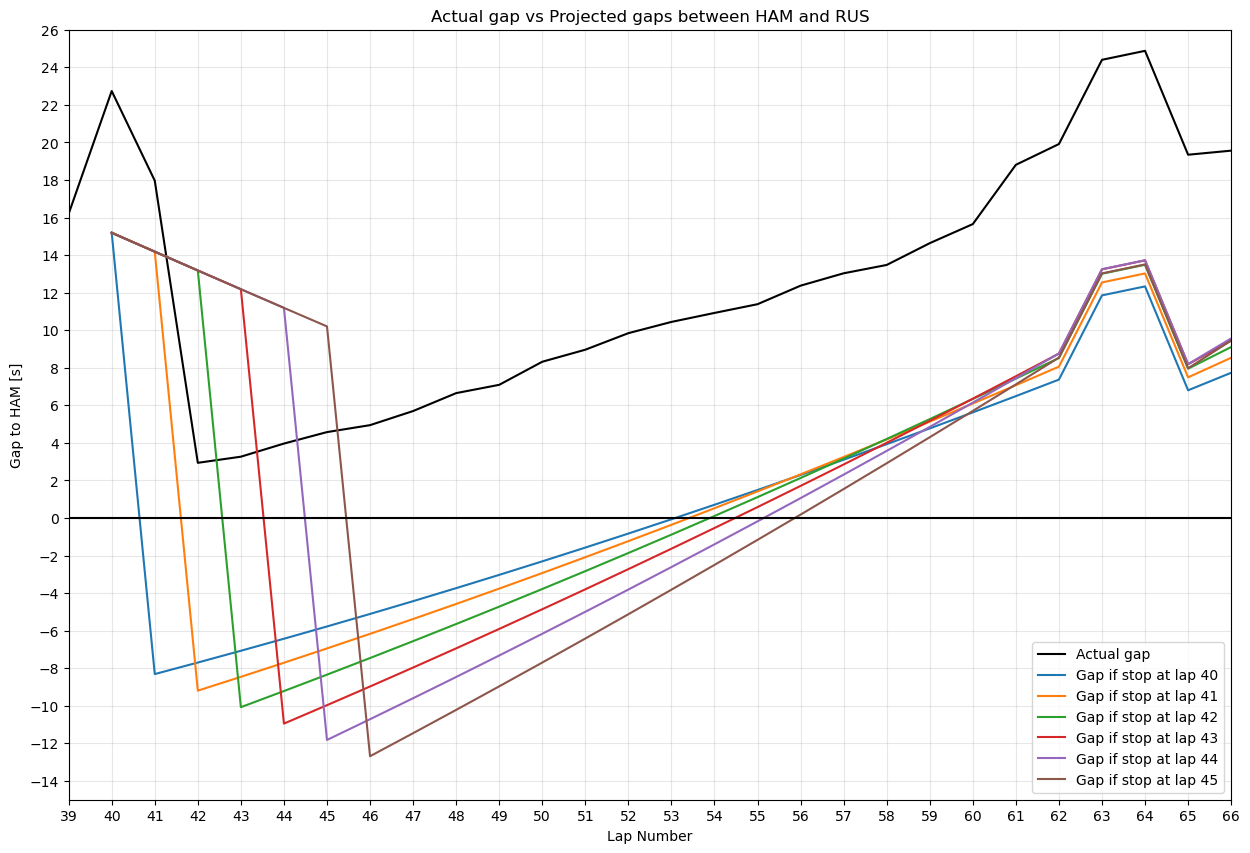

In [85]:
#Visualize the predicted gaps for each n against the actual gap

fig, ax = plt.subplots(figsize=(15, 10))

sns.lineplot(x='LapNumber', y='gap', data=gap_drivers(RUS, HAM),
             color='black', ax=ax, label = 'Actual gap')

for n in range(40, 46):
    sns.lineplot(x='LapNumber', y='gap', data=gap(ham_time_stop(HAM, n), rus_time(RUS)), label=f'Gap if stop at lap {n}',ax=ax)

ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
ax.set_xlim(39, 66)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
plt.grid(axis='x', alpha=0.3)
plt.grid(axis='y', alpha=0.3)
ax.set_ylim(-15, 26)
plt.xlabel('Lap Number')
plt.ylabel('Gap to HAM [s]')
plt.title('Actual gap vs Projected gaps between HAM and RUS')
plt.show()